# construct mock observations

In [1]:
import os, sys
import numpy as np 

In [2]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
omega_true = np.array([-1.65, -1.5, -0.2, -19.5, 6e-3]) 

## luminosity function

(2e-05, 0.1)

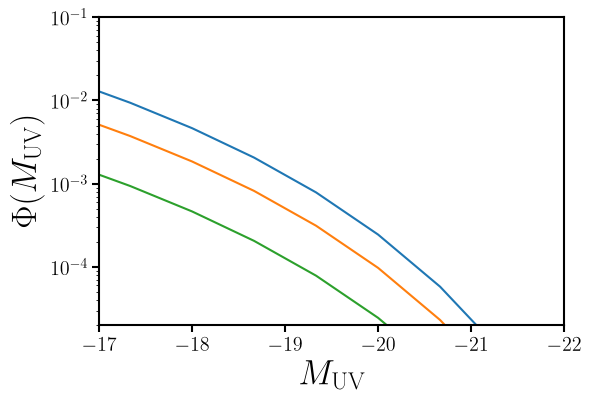

In [5]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)
Muv_bin = np.linspace(-16, -22, 10)
for i, z in enumerate([9., 11., 14.]): 
    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), label=r'$z = %.0f' % z)
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-17, -22)
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
sub.set_yscale('log') 
sub.set_ylim(2e-5, 1e-1)

## selection function

In [6]:
unif_Muv = np.random.uniform(-22, -14, size=int(1e6))
unif_z = np.random.uniform(5, 16, size=int(1e6))

In [7]:
select = FM.selection_function(np.vstack([unif_z, unif_Muv]).T, name='z9')

In [8]:
h, bx, by = np.histogram2d(unif_z, unif_Muv, bins=[70, 60], range=[(4.99, 16.01), (-22.01, -13.99)])
h_select, _, _ = np.histogram2d(unif_z[select], unif_Muv[select], bins=[70, 60], range=[(4.99, 16.01), (-22.01, -13.99)])

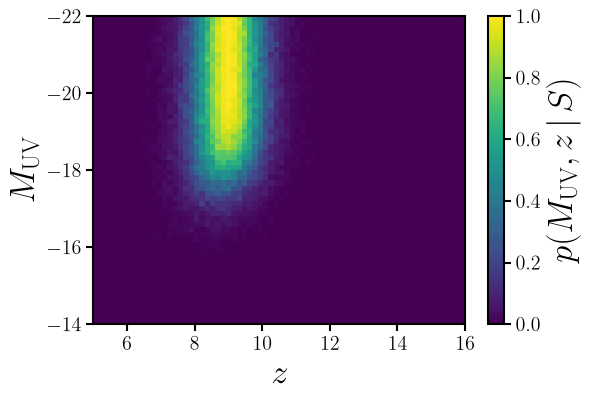

In [9]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)
X, Y = np.meshgrid(bx, by)
p = sub.pcolormesh(X, Y, (h_select/h).T, vmin=0., vmax=1.)

plt.colorbar(p).set_label(r'$p(M_{\rm UV}, z\,|\,S)$', size=25)
sub.set_xlabel('$z$', fontsize=25)
sub.set_xlim(5, 16)
sub.set_ylabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_ylim(-14, -22)
fig.savefig('mock_select.pdf', bbox_inches='tight') 

## apply realistic noise based on Finkelstein et al. (2023)

In [10]:
# sample LF 
mock = FM.sampleLF(omega_true[:-1], phi_amp=omega_true[-1])
select_z9 = FM.selection_function(mock, name='z9')
select_z11 = FM.selection_function(mock, name='z11')
select_z14 = FM.selection_function(mock, name='z14')

# linear relation derived from with scatter
sig_photoz, sig_Muv = [], [] 
for i in range(mock.shape[0]): 
    _sig_photoz = 0 
    while _sig_photoz < 0.03 or _sig_photoz > 1: 
        _sig_photoz = (0.125 * mock[i,0] - 0.74) + 0.3 * np.random.normal()

    _sig_Muv = 0 
    while _sig_Muv < 0.01 or _sig_Muv > 0.4: 
        _sig_Muv = (0.1 * mock[i,1] + 1.94) + 0.08 * np.random.normal()

    sig_photoz.append(_sig_photoz)
    sig_Muv.append(_sig_Muv)

sig_photoz = np.array(sig_photoz)
sig_Muv = np.array(sig_Muv)

mock_photoz = mock[:,0] + sig_photoz * np.random.normal(size=mock.shape[0])
mock_Muv = mock[:,1] + sig_Muv * np.random.normal(size=mock.shape[0])

X_obs0 = np.vstack([mock_photoz, mock_Muv, sig_photoz, sig_Muv]).T[select_z9]
X_obs1 = np.vstack([mock_photoz, mock_Muv, sig_photoz, sig_Muv]).T[select_z11]
X_obs2 = np.vstack([mock_photoz, mock_Muv, sig_photoz, sig_Muv]).T[select_z14]

## plot data

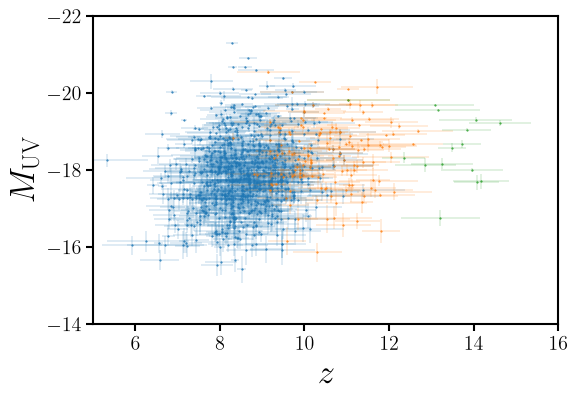

In [11]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)
sub.errorbar(X_obs0[:,0], X_obs0[:,1], xerr=X_obs0[:,2], yerr=X_obs0[:,3], fmt='.C0', elinewidth=0.2, markersize=1, rasterized=True)
sub.errorbar(X_obs1[:,0], X_obs1[:,1], xerr=X_obs1[:,2], yerr=X_obs1[:,3], fmt='.C1', elinewidth=0.2, markersize=1, rasterized=True)
sub.errorbar(X_obs2[:,0], X_obs2[:,1], xerr=X_obs2[:,2], yerr=X_obs2[:,3], fmt='.C2', elinewidth=0.2, markersize=1, rasterized=True)

sub.set_xlabel('$z$', fontsize=25)
sub.set_xlim(5, 16)
sub.set_ylabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_ylim(-14, -22)
fig.savefig('mock_obs.pdf', bbox_inches='tight') 

# save to file

In [12]:
np.save('/Users/ch54662/data/px2cosmo/mock/omega_true.npy', omega_true)
np.save('/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy', X_obs0)
np.save('/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy', X_obs1)
np.save('/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy', X_obs2)